# **ИНТЕРНЕТ-МАГАЗИН «СТРИМЧИК»**

**Цель исследования:**
1. Изучить данные интернет-магазина «Стримчик»: данные по продаже игр, их оценка пользователями и критиками, их жанры, платформы и возрастные рейтинги.
2. Выявить закономерности, определяющие коммерческий успех игры (объём мировых продаж).
3. Составить портрет типичного игрока в каждом из регионов (Северная Америка, Европа, Япония).
4. Проверить гипотезы, которые помогут оптимизировать подбор игр и планирование маркетинговых кампаний.

**Ход исследования:**

Данные я получу из одного CSV-файла с историческими данными о продажах игр. Известно, что данные представлены на декабрь 2016 года, и что данные за 2016 год могут быть неполными. О качестве данных изначально ничего не известно, потребуется предобработка (приведение типов, обработка пропусков, создание новых признаков). После этого проведу исследовательский анализ: изучу динамику выпуска игр по годам, распределение продаж по платформам и жанрам, выделю актуальный период для прогноза на 2017 год. Затем составлю портрет пользователя по регионам и проверю статистические гипотезы о влиянии оценок и жанров на продажи. Наконец, сформулирую общий вывод и рекомендации.

Таким образом, моё исследование пройдёт в шесть основных этапов:

- Шаг 1. Загрузка данных
- Шаг 2. Предобработка данных
    - 2.1 Нормализация названий столбцов
    - 2.2 Преобразование типов данных
    - 2.3 Обработка пропусков
    - 2.4 Проверка на наличие дубликатов
    - 2.5 Подсчёт суммарных продаж во всех регионах
    - 2.6 Вывод подраздела
- Шаг 3. Исследовательский анализ данных
    - 3.1 Количество игр в разные годы
    - 3.2 Продажи игр в разрезе платформ
    - 3.3 Жизненный цикл платформ
    - 3.4 Актуальные игровые платформы
    - 3.5 Определение актуального периода
    - 3.6 Лидеры продаж за актуальный период
    - 3.7 Ящик с усами
    - 3.8 Влияние отзывов на продажи
    - 3.9 Распределение по жанрам
    - 3.10 Вывод подраздела
- Шаг 4. Портрет пользователя по регионам
    - 4.1 Популярные платформы
    - 4.2 Популярные жанры
    - 4.3 Влияние рейтинга ESRB
    - 4.4 Вывод подраздела
- Шаг 5. Проверка гипотез
    - 5.1 Пользовательские рейтинги Xbox One и PC одинаковые
    - 5.2 Пользовательские рейтинги Action и Sports разные
    - 5.3 Вывод подраздела
- Шаг 6. Общий вывод

<a id="step-1"></a>
## Шаг 1. Загрузка данных

In [1]:
import pandas  as pd
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/crumblinq/videogame-market-analysis/main/datasets/games.csv')
display(df.head(10))

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


**Комментарии:**

Прочитали CSV-файл с данными об играх с помощью библиотеки `pandas` и сохранили их в датафрейм `games`.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


**Комментарии:**

Вывели первые строки набора данных. Изучили общую информацию из файла.

Нам дан 1 файл с информацией об играх до 2016 года включительно. В файле содержится информация о названии игры, платформе, на которой игра вышла, жанр игры, продажи в разных регионах (`NA` - Северная Америка, `EU` - Европа, `JP` - Япония), оценки критиков, оценки пользователей, возрастной рейтинг.

Отметим пропущенные значения в колонках `Name`, `Year_of_Release`, `Genre`, `Critic_Score`, `User_Score` и `Rating`.

<a id="step-2"></a>
## Шаг 2. Предобработка данных

<a id="step-2-1"></a>
### 2.1 Нормализация названий столбцов

In [4]:
df.columns = df.columns.str.lower()
display(df.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


**Комментарии:**

Привели названия столбцов к общей стилистике, приведя их к нижнему регистру.

<a id="step-2-2"></a>
### 2.2 Преобразование типов данных

In [5]:
df['year_of_release'] = df['year_of_release'].astype('Int64')

df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
df['user_score'] = df['user_score'].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


**Комментарии:**

Привели колонку `year_of_release` к корректному типу данных - `Int64`, потому что год - всегда целое число, при этом в столбце есть пропуски.

Колонка `critic_score` оставлена в числовом формате с пропусками для дальнейшего коэффициента корреляции.

Привели колонку `user_score` к корректному типу данных - `float64`, потому что оценка пользователей число дробное. Но для начала заменяем значения `tbd` на пропуски. Текст `tbd` обозначает, что оценка появится в будущем. Для нас не критично появление оценки в будущем, потому что в настоящем у такой игры нет оценки. Унифицируем, и приходим к тому, чтобы и `NaN`, и `tbd` обозначать как пропуск (`NaN`).

Произвели проверку, чтобы убедиться что изменения вступили в силу. Все колонки приведены к правильному типу данных, преобразования корректны.

<a id="step-2-3"></a>
### 2.3 Обработка пропусков

In [6]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [7]:
pd.DataFrame(round(df.isna().mean()*100,1)).style.background_gradient('coolwarm')

,0
name,0.000000
platform,0.000000
year_of_release,1.600000
genre,0.000000
na_sales,0.000000
eu_sales,0.000000
jp_sales,0.000000
other_sales,0.000000
critic_score,51.300000
user_score,54.600000


**Комментарии:**

Подсчитали количество пропусков для каждой колонны и определили их долю. Пропущенные значения имеются в колонках `name`, `year_of_release`, `genre`, `critic_score`, `user_score`, `rating`.

- `name` - критически важная величина, без названия игры все прочие данные для нас бесполезны. Поэтому строки с пропусками в `name` убираем из датафрейма. Возможно, данные отсутствуют из-за технической ошибки, либо у игры не было официального названия

- `year_of_release` - год выпуска важен для дальнейшего анализа, но так как такие пропуски составляют лишь малую долю (1.6%), их можно удалить

- `genre` - пропуски этого колонки перестают иметь место после удаления строк с незаполненным `name`, то есть данные взаимосвязаны.

- `critic_score` - пропусков слишком много (51.3%), оставляем как есть. Невозможно правильно присвоить значения. Если присваивать медианну, то нужно учитывать очень много факторов, которые не всегда являются объективной метрикой, а пропусков слишком много и это может неправильно повлиять на дальнейший анализ данных. Как правило, нет оценки, если игра малоизвестная и критики "обошли стороной" или она еще не успела получить обзоры критиков.

- `user_score` - значения с `tbd` уже частично обработаны. Пропусков слишком много (54.6%), оставляем как есть. Невозможно правильно присвоить значения. Если присваивать медианну, то нужно учитывать очень много факторов, которые не всегда являются объективной метрикой, а пропусков слишком много и это может неправильно повлиять на дальнейший анализ данных. Нет оценки, если игра еще не вышла или вышла недавно, либо слишком малоизвестная.

- `rating` - тип данных `object`. для таких игр с незаполненным рейтингом можно создать свою категорию. Возможно, такая игра вышла до введения рейтинга ESRB, либо по другим причинам. 

In [8]:
df = df.dropna(subset=['name', 'year_of_release'])
df['rating'] = df['rating'].fillna('No Rating')

display(df.isna().sum())

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
dtype: int64

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.5+ MB
None


**Комментарии:**

Пропущенные значения были обработаны там, где это возможно. Изменения "до" и "после" зафиксированы. Данные датафрейма готовы к следующему шагу.

<a id="step-2-4"></a>
### 2.4 Проверка на наличие дубликатов

#### Полные дубликаты

In [10]:
print(f'Найдено полных дубликатов: {df.duplicated().sum()}')

Найдено полных дубликатов: 0


#### Неявные дубликаты

In [11]:
implicit_duplicates = df[df[['name', 'platform','year_of_release']].duplicated(keep=False)]

display(implicit_duplicates)
print(f'Найдено неявных дубликатов: {len(implicit_duplicates)} записи')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E


Найдено неявных дубликатов: 2 записи


In [12]:
df = df.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16443 non-null  object 
 2   year_of_release  16443 non-null  Int64  
 3   genre            16443 non-null  object 
 4   na_sales         16443 non-null  float64
 5   eu_sales         16443 non-null  float64
 6   jp_sales         16443 non-null  float64
 7   other_sales      16443 non-null  float64
 8   critic_score     7982 non-null   float64
 9   user_score       7462 non-null   float64
 10  rating           16443 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.5+ MB


In [13]:
implicit_duplicates = df[df[['name', 'platform','year_of_release']].duplicated(keep=False)]

display(implicit_duplicates)
print(f'Найдено неявных дубликатов (повторная проверка): {len(implicit_duplicates)} записей')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


Найдено неявных дубликатов (повторная проверка): 0 записей


**Комментарии:**

Полных дубликатов не найдено.

Неявных дубликатов было найдено: 2 записи, 1 игра. Так как неизвестно, у Madden NFL 13 в `eu_sales` во второй записи 0.01 это действительные верные дополнительные данные, которые следует сложить с первой записью, или какая-то ошибка данных, то было принято решение не складывать европейские продажи, а работать с имеющейся полной первой записью, а другую отбросить. Проверка показала, что мы действительно удалили 1 запись, и неявных дубликатов больше нет.

#### Прочие дубликаты

In [14]:
name_duplicates = df[df['name'].duplicated(keep=False)].sort_values('name')

print(f'Найдено дубликатов по названию игры: {len(name_duplicates)}')
print(f"Из них уникальных названий: {name_duplicates['name'].nunique()}")
display(name_duplicates)

Найдено дубликатов по названию игры: 7765
Из них уникальных названий: 2748


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
3862,Frozen: Olaf's Quest,DS,2013,Platform,0.21,0.26,0.00,0.04,NaN,NaN,No Rating
3358,Frozen: Olaf's Quest,3DS,2013,Platform,0.27,0.27,0.00,0.05,NaN,NaN,No Rating
14658,007: Quantum of Solace,PC,2008,Action,0.01,0.01,0.00,0.00,70.0,6.3,T
1285,007: Quantum of Solace,X360,2008,Action,0.82,0.51,0.01,0.14,65.0,7.1,T
1785,007: Quantum of Solace,PS3,2008,Action,0.43,0.51,0.02,0.19,65.0,6.6,T
...,...,...,...,...,...,...,...,...,...,...,...
3304,pro evolution soccer 2011,X360,2010,Sports,0.09,0.44,0.00,0.07,79.0,5.9,E
4664,pro evolution soccer 2011,PS2,2010,Sports,0.04,0.21,0.05,0.11,NaN,6.7,E
7149,pro evolution soccer 2011,Wii,2010,Sports,0.07,0.10,0.03,0.02,78.0,5.4,E
8280,uDraw Studio: Instant Artist,Wii,2011,Misc,0.06,0.09,0.00,0.02,NaN,NaN,E


**Комментарии:**

Отметим, что игры в этом наборе данных могут иметь одинаковые названия, но выходить на разные платформы, и при этом иметь разные оценки и продажи в зависимости от платформы (7765 строк подобных дубликатов, из них - 2748 с уникальным названием). Такие записи "дубликатов" трогать не будем.

<a id="step-2-5"></a>
### 2.5 Подсчёт суммарных продаж во всех регионах

In [15]:
df['total_sales'] = (df['na_sales']+ df['eu_sales'] + df['jp_sales'] + df['other_sales'])
display(df.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,No Rating,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,No Rating,31.38


**Комментарии:**

Cуммарные продажи во всех регионах подсчитаны и записаны в отдельный столбец.

<a id="step-2-6"></a>
### 2.6 Вывод подраздела

Столбцы в датафрейме были приведены к нижнему регистру, что сделало код более читаемым и избавило от ошибок при обращении к ним.

Типы данных были приведены к более корректному типу:
- `year_of_release` - в `Int64` как целое число
- `critic_score` и `user_score` - в `float64`, превратили строки `tbd` в `NaN` и подготовили столбцы к вычислениям и визуализации

Обработали пропуски:
- `name`, `year_of_release` - записи с пропусками удалены
- `critic_score` - оставлены с `NaN`, потому что заполнение медианой или другими значениями могло бы исказить выборку и дальнейший анализ
- `user_score` - значения `tbd`(to be determined) были оценены как фактическое отсутствие оценки и превращены в `NaN`
- `rating` - пропуски заменены на `No Rating`, чтобы учесть в дальнейшем анализе категорий без отмеченного рейтинга

Создание новой колонки `total_sales` (общая сумма продаж) необходимо для дальнейших подсчетов и сравнений продаж.

Таким образом, все данные датафрейма готовы к следующему шагу.

<a id="step-3"></a>
## Шаг 3. Исследовательский анализ данных

Проведем анализ исторических данных о продажах игр, чтобы выявить ключевые особенности развития платформ и жанров, определить жизненный цикл платформ и подобрать актуальные данные для будущего прогноза на 2017 год. Помимо этого, рассмотрим влияние оценок критиков и пользователей на успешность продаж в разрезе разных платформ, установить зависимости этих переменных между собой.

<a id="step-3-1"></a>
### 3.1 Количество игр в разных годы

Посмотрим сколько игр выпускалось в разные года. Важны ли данные за все периоды?

In [16]:
years_amount = df.groupby('year_of_release').size()

print(f'Количество лет в выборке: {len(years_amount)}')
print()
print(years_amount.describe())

Количество лет в выборке: 37

count      37.000000
mean      444.405405
std       451.591535
min         9.000000
25%        36.000000
50%       338.000000
75%       762.000000
max      1427.000000
dtype: float64


In [17]:
top_10_by_years = years_amount.sort_values(ascending=False).head(10)

print('Самые продуктивные годы игровой индустрии (год, кол-во выпущенных игр):')
display(top_10_by_years)

Самые продуктивные годы игровой индустрии (год, кол-во выпущенных игр):


year_of_release
2008    1427
2009    1426
2010    1255
2007    1197
2011    1136
2006    1006
2005     939
2002     829
2003     775
2004     762
dtype: int64

In [18]:
last_10_years = years_amount.tail(10)

print('Количество игр за последние 10 лет (2007-2016) (год, кол-во выпущенных игр):')
display(last_10_years)

Количество игр за последние 10 лет (2007-2016) (год, кол-во выпущенных игр):


year_of_release
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     652
2013     544
2014     581
2015     606
2016     502
dtype: int64

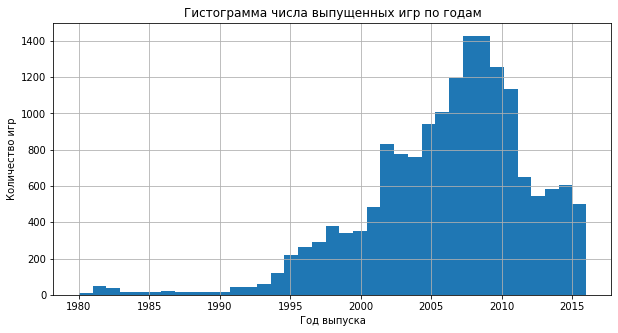

In [19]:
plt.figure(figsize=(10, 5))
df['year_of_release'].hist(bins=37)
plt.title('Гистограмма числа выпущенных игр по годам')
plt.xlabel('Год выпуска')
plt.ylabel('Количество игр')

plt.show()

**Комментарии:**

Данные распределены неравномерно - до 1995 года выпускалось значительно мало игр, а основной рост производства игр начинается с 2000-х годов. Для дальнейшего исследовательского анализа данных напомним, что данные за 2016 год неполные.

Почему стоит делать анализ (как минимум) с 2000 года:
- начало нового тысячелетия, игровая техника развились до уровня, который мы привыкли видеть, и далее идет только их усовершенствование, более актуальные серии игр
- в этот период игровая индустрия прошла стадию активного роста с 2000 года, пик в 2008 году и наблюдает дальнейшee уменьшение выпуска игр с 2010 года
- гистограмма с промежутка 2000 по 2016 практически симметрична, а это может говорить о стабилизации индустрии

Окончательный актуальный период для прогноза на 2017 год будет определен отдельно далее.

<a id="step-3-2"></a>
### 3.2 Продажи игр в разрезе платформ

Посмотрим как менялись продажи игр по платформам. Выберем платформы с наибольшими продажами игр за все время, а затем построим распределение по годам.

#### 3.2.1 За все время (1980-2016)

In [20]:
sales_by_platform = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
top10_platform = sales_by_platform.head(10)

print('Топ 10 продаж по платформам за все время (1980-2016):')
display(top10_platform)

Топ 10 продаж по платформам за все время (1980-2016):


platform
PS2     1233.56
X360     961.24
PS3      931.33
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

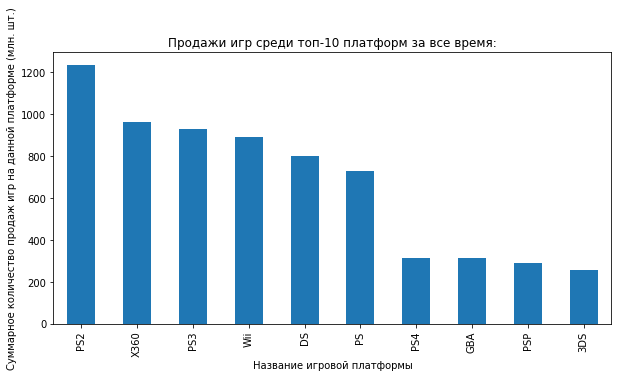

In [21]:
ax = top10_platform.plot(
    kind='bar',
    figsize=(10, 5),
    title='Продажи игр среди топ-10 платформ за все время:'
)

plt.xlabel('Название игровой платформы')
plt.ylabel('Суммарное количество продаж игр на данной платформе (млн. шт.)')
plt.show()

**Комментарии:**

С 1980 по 2016 год больше всего игры продавались на платформах:
1. PlayStation 2 - 1.26 миллиарда игр (1255.77 миллионов)
2. Xbox 360 - 971.42 миллиона игр
3. PlayStation 3 - 939.65 миллиона игр
4. Nintendo Wii - 907.51 миллиона игр
5. Nintendo DS - 806.12 миллиона игр

#### 3.2.2 За последние десять лет (2007-2016)

In [22]:
top10_df = (
    df.groupby('platform')['total_sales'].sum()
      .sort_values(ascending=False)
      .reset_index(name='sales')
      .head(10)
)

sales_by_year_grouped_on_platform = (
    df[df['platform'].isin(top10_df['platform'])].pivot_table(
         index='year_of_release',
         columns='platform',
         values='total_sales',
         aggfunc='sum'
      )
)

print(f'Продажи за последние 10 лет (2007-2016) среди топ 10 платформ:')
display(sales_by_year_grouped_on_platform.fillna(0).tail(10))

Продажи за последние 10 лет (2007-2016) среди топ 10 платформ:


platform,3DS,DS,GBA,PS,PS2,PS3,PS4,PSP,Wii,X360
year_of_release,,,,,,,,,,
2007,0.00,146.94,3.4,0.0,75.99,73.19,0.00,46.93,152.77,95.41
2008,0.00,145.31,0.0,0.0,53.90,118.52,0.00,34.55,171.32,135.26
2009,0.00,119.54,0.0,0.0,26.40,130.93,0.00,37.78,206.97,120.29
2010,0.00,85.02,0.0,0.0,5.64,142.17,0.00,35.04,127.95,170.03
2011,63.20,26.18,0.0,0.0,0.45,156.78,0.00,17.82,59.65,143.84
2012,51.36,11.01,0.0,0.0,0.00,107.35,0.00,7.69,21.71,99.74
2013,56.57,1.54,0.0,0.0,0.00,113.25,25.99,3.14,8.59,88.58
2014,43.76,0.00,0.0,0.0,0.00,47.76,100.00,0.24,3.75,34.74
2015,27.78,0.00,0.0,0.0,0.00,16.82,118.90,0.12,1.14,11.96


**Комментарии:**

Из таблицы распределения продаж по годам, мы видим, что некоторые платформы устаревают, и продажи сходят на нет. Однако, не стоит забывать, что предоставленные данные за 2016 год - неполные. Для наглядности визуализируем таблицу по топ 10 платформами без учета 2016 года.

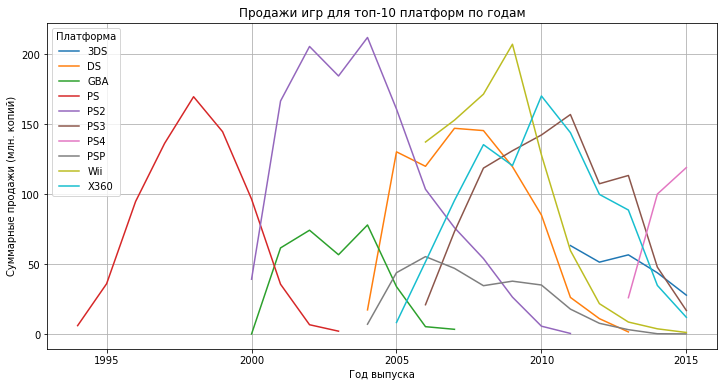

In [23]:
sales_plot = sales_by_year_grouped_on_platform.query('1986 <= year_of_release <= 2015')

ax1 = sales_plot.plot(figsize=(12, 6), grid=True)
ax1.set_title('Продажи игр для топ-10 платформ по годам')
ax1.set_xlabel('Год выпуска')
ax1.set_ylabel('Суммарные продажи (млн. копий)')
ax1.legend(title='Платформа')

plt.show()

**Комментарии:**

По данному графику видно, что консоли - вещь недолговечная, и каждая имеет свой срок жизни и пик популярности. Найдем характерный срок, за который появляются и исчезают игровые консоли.

<a id="step-3-3"></a>
### 3.3 Жизненный цикл платформ

In [24]:
platform_age = (df[['platform', 'year_of_release']]
  .dropna()
  .drop_duplicates()
  .groupby('platform')
  .size()
)

display(platform_age.head())
print(platform_age.describe())

platform
2600    10
3DO      2
3DS      6
DC       7
DS      11
dtype: int64

count    31.000000
mean      7.677419
std       5.081910
min       1.000000
25%       4.000000
50%       7.000000
75%      11.000000
max      26.000000
dtype: float64


In [25]:
platform_age_median = platform_age.median()
print(f'Медианный срок жизни консоли: {platform_age_median} лет')

years_amount_count = len(years_amount)
print(f'Количество лет в выборке: {years_amount_count}')

platform_count = platform_age.count()
print(f'Количество игровых платформ с 1980 по 2016 год: {platform_count}')

print(f'Новая игровая консоль появляется каждые {(years_amount_count / platform_count):.1f} года')

Медианный срок жизни консоли: 7.0 лет
Количество лет в выборке: 37
Количество игровых платформ с 1980 по 2016 год: 31
Новая игровая консоль появляется каждые 1.2 года


**Комментарии:**

Проанализировали срок службы 31 игровой консоли за период с 1980 по 2016 год:

Средняя "жизнь" игровой платформы - 7,7 лет. Но при наличии "долгожителей" типа PC и неудачных игровых решений, правильным будет смотреть на медианное значение - 7.0 лет. Поэтому делаем вывод, что срок жизни консоли - около 7 лет.

Отдельно отметим, что стандартное отклонение составляет ~5 лет. Это значит, что консоли обычно могут "жить" от 2,7 до 12,7 лет.

С 1980 по 2016 год в среднем новая игровая консоль появлялась примерно раз в 1.2 лет (почти каждый год).

<a id="step-3-4"></a>
###  3.4 Актуальные игровые платформы

####  3.4.1 Определение актуальных игровых платформ

В данном проекте актуальными платформами будут считаться те платформы, на которые игры продолжают выходить в 2016 году.

In [26]:
platform_period = (
    df.groupby('platform')['year_of_release']
    .agg(['min', 'max'])
    .reset_index()
)

platform_period.columns = ['platform', 'first_year', 'last_year']
platform_period['life_cycle'] = platform_period['last_year'] - platform_period['first_year'] + 1
platform_period = platform_period.sort_values(['last_year', 'life_cycle'], ascending=[False, True]).reset_index(drop=True)

display(platform_period.head(10))

,platform,first_year,last_year,life_cycle
0,PS4,2013,2016,4
1,XOne,2013,2016,4
2,WiiU,2012,2016,5
3,3DS,2011,2016,6
4,PSV,2011,2016,6
5,PS3,2006,2016,11
6,Wii,2006,2016,11
7,X360,2005,2016,12
8,PC,1985,2016,32
9,PSP,2004,2015,12


**Комментарии:**
    
Отобразили современные актуальные на 2016 игровые платформы в виде таблицы. Под критерий актуальных платформ подходят: `PS4`, `XOne`, `WiiU`, `3DS`,`PSV`, `PS3`, `Wii`, `X360`, `PC`. 

В данной таблице `PSP` представлен для наглядности и не относится к актуальным, так как игры на эту консоль (по представленной информации на декабрь 2016) в 2016 году не выходили.

#### 3.4.2 Продажи игр на актуальных платформах

Рассмотрим количество продаж игр для актуальных платформ за последние 10 лет.

In [27]:
platforms_2016 = platform_period.query('last_year == 2016')['platform']

sales_2016 = (
    df[df['platform'].isin(platforms_2016)].pivot_table(
        index='year_of_release',
        columns='platform',
        values='total_sales',
        aggfunc='sum'
    )
)

total_sales = (
    df[df['platform'].isin(platforms_2016)]
    .groupby('year_of_release')['total_sales']
    .sum()
)

sales_2016['total_sales'] = total_sales

display(sales_2016.fillna(0).tail(10))

platform,3DS,PC,PS3,PS4,PSV,Wii,WiiU,X360,XOne,total_sales
year_of_release,,,,,,,,,,
2007,0.00,9.28,73.19,0.00,0.00,152.77,0.00,95.41,0.00,330.65
2008,0.00,12.42,118.52,0.00,0.00,171.32,0.00,135.26,0.00,437.52
2009,0.00,16.91,130.93,0.00,0.00,206.97,0.00,120.29,0.00,475.10
2010,0.00,24.28,142.17,0.00,0.00,127.95,0.00,170.03,0.00,464.43
2011,63.20,35.03,156.78,0.00,4.63,59.65,0.00,143.84,0.00,463.13
2012,51.36,23.22,107.35,0.00,16.19,21.71,17.56,99.74,0.00,337.13
2013,56.57,12.38,113.25,25.99,10.59,8.59,21.65,88.58,18.96,356.56
2014,43.76,13.28,47.76,100.00,11.90,3.75,22.03,34.74,54.07,331.29
2015,27.78,8.52,16.82,118.90,6.25,1.14,16.35,11.96,60.14,267.86


**Комментарии:**
    
Еще раз отметим, что по полученной изначально информации, данные за 2016 могут быть неполными, поэтому их нужно использовать осторожно. Рассмотрим график продаж за последние 10 лет, при этом данные за 2016 отображать не будем.

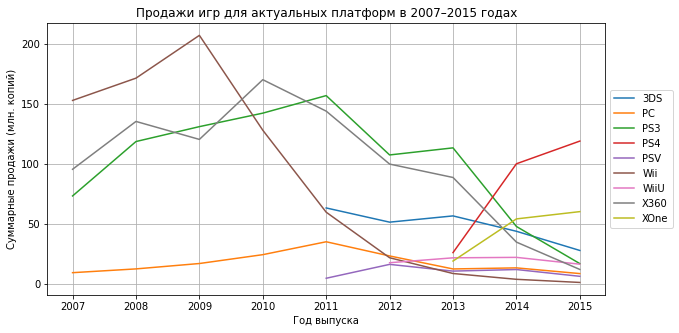

In [28]:
ax1 = sales_2016.loc[2007:2015].drop(columns='total_sales').plot(figsize=(10, 5), grid=True)
ax1.set_title('Продажи игр для актуальных платформ в 2007–2015 годах')
ax1.set_xlabel('Год выпуска')
ax1.set_ylabel('Суммарные продажи (млн. копий)')
ax1.legend(title='Платформа')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show();

**Комментарии:**
    
Подтвердим, что "продажи игр на актуальных платформах за последние 10 лет" не равно "продажам игр топ-10 платформ за последние 10 лет".

Отметим рост продаж игр на новых игровых платформ в 2015 году (PS4 и Xbox One), в то время как остальные платформы демонстрируют спад.

#### 3.4.3 Жизненный цикл актуальных игровых платформ

Рассмотрим текущее состояние актуальных платформ на 2016 год и построим график для наглядности.

In [29]:
display(platform_period.head(9))

,platform,first_year,last_year,life_cycle
0,PS4,2013,2016,4
1,XOne,2013,2016,4
2,WiiU,2012,2016,5
3,3DS,2011,2016,6
4,PSV,2011,2016,6
5,PS3,2006,2016,11
6,Wii,2006,2016,11
7,X360,2005,2016,12
8,PC,1985,2016,32


**Комментарии:**
    
Объединим данные, получененные из шагов `3.3` и `3.4.1`.

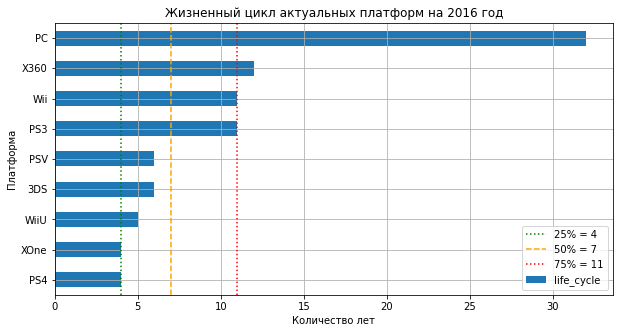

In [30]:
ax = (
    platform_period.loc[platform_period['last_year'] == 2016]
    .sort_values('life_cycle')
    .plot(
        x='platform',
        y='life_cycle',
        kind='barh',
        figsize=(10, 5),
        grid=True,
        legend=False
    )
)

ax.set_title('Жизненный цикл актуальных платформ на 2016 год')
ax.set_xlabel('Количество лет')
ax.set_ylabel('Платформа')

ax.axvline(4, linestyle=':', color='green', label='25% = 4')
ax.axvline(7, linestyle='--', color='orange', label='50% = 7')
ax.axvline(11, linestyle=':', color='red', label='75% = 11')

ax.legend()
plt.show()

**Комментарии:**
    
Как было выявлено ранее, срок жизни консоли примерно 7 лет (`Шаг 3.3`). 

Из графика видно,  что в 2016 году PS4 и Xbox One находятся в середине жизненного цикла (на пике), и могут рассматриваться на как потенциально прибыльные платформы.

<a id="step-3-5"></a>
###  3.5 Определение актуального периода для проведения анализа

Для определения актуального периода рассмотрим игровые платформы, которые есть в настоящее время (`Шаг 3.4.2`). Так как Xbox One и PS4 потенциально прибыльные (`Шаг 3.4.3`), помимо них посмотрим остальные платформы.

Для дальнейшего анализа, выберем актуальный период с 2013-2016, потому что именно в 2013 году появляются новое поколение консолей (PS4 и Xbox One) и их появление лучше отображает текущую ситуацию на рынке игр. График представлен ниже.

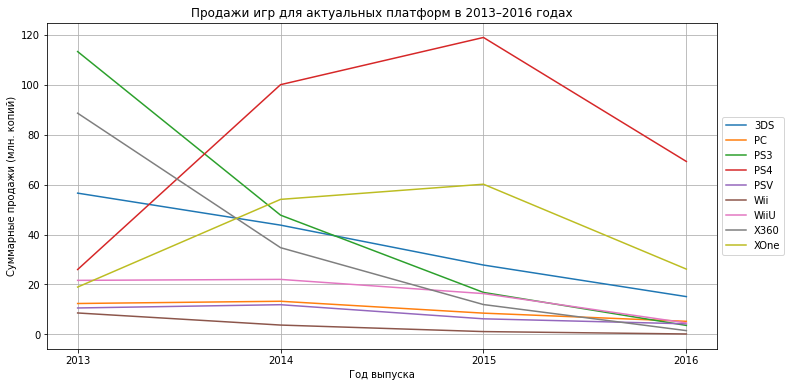

In [31]:
ax1 = sales_2016.loc[2013:2016].drop(columns='total_sales').plot(figsize=(12, 6), grid=True)
ax1.set_title('Продажи игр для актуальных платформ в 2013–2016 годах')
ax1.set_xlabel('Год выпуска')
ax1.set_ylabel('Суммарные продажи (млн. копий)')
ax1.legend(title='Платформа')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.set_xticks(range(2013, 2017))

plt.show()

**Комментарии:**

Несмотря на то, что данные за 2016 неполные, их следует учитывать при планировании будущих рекламных кампаний, так как это наиболее "свежие" данные о продажах и они помогут построить прогноз на 2017 год.

Как мы видим, по состоянию на конец 2015 года лидером является PS4 c 118.9 миллионами продаж, далее идет Xbox One с 60.14 миллионами. Эти две платформы в продаже с 2013 года, они демонстрируют рост и должны выйти на пик в 2016 году.

Все остальные платформы демонстрируют падение - в 2016 году игры на PSP больше не продаются, а продажи для PS3 и Xbox 360 упали в 7 раз и более устаревшее поколение консолей постепенно завершают свой жизненный цикл.

<a id="step-3-6"></a>
### 3.6 Лидеры продаж за актуальный период

In [32]:
platforms_in_2016 = ['PC', 'X360', 'Wii', 'PS3', 'PSV', '3DS', 'WiiU', 'XOne', 'PS4']
start_year = 2013
end_year = 2016

df_period_filters = df[
    df['platform'].isin(platforms_in_2016) &
    (df['year_of_release'] >= start_year) &
    (df['year_of_release'] <= end_year)
]

sales_until_2015_pivot = df_period_filters.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

sales_until_2015_pivot.loc['total_sales'] = sales_until_2015_pivot.sum()

sales_until_2015_pivot = sales_until_2015_pivot[
    sales_until_2015_pivot.loc['total_sales'].sort_values(ascending=False).index
]

display(sales_until_2015_pivot)

platform,PS4,PS3,XOne,3DS,X360,WiiU,PC,PSV,Wii
year_of_release,,,,,,,,,
2013,25.99,113.25,18.96,56.57,88.58,21.65,12.38,10.59,8.59
2014,100.00,47.76,54.07,43.76,34.74,22.03,13.28,11.90,3.75
2015,118.90,16.82,60.14,27.78,11.96,16.35,8.52,6.25,1.14
2016,69.25,3.60,26.15,15.14,1.52,4.60,5.25,4.25,0.18
total_sales,314.14,181.43,159.32,143.25,136.80,64.63,39.43,32.99,13.66


**Комментарии:**

Самые продающие платформы за с 2013 по неполный 2016 год: 
- PS4 (314,14 млн. копий), 
- PS3 (181,43 млн. копий), 
- XOne (159,32 млн. копий), 
- 3DS (143,25 млн. копий), 
- X360 (136.80 млн. копий)

Однако, следует отметить, что с выходом нового поколения, PS3 и X360 ощущают значительный спад, поэтому рекламным кампаниям в выборе консоли стоит учитывать следующий приоритет: 

1. PS4, 
2. XOne, 
3. 3DS.

<a id="step-3-7"></a>
### 3.7 «Ящик с усами»

Построим график «ящик с усами» по глобальным продажам игр в разбивке по платформам.

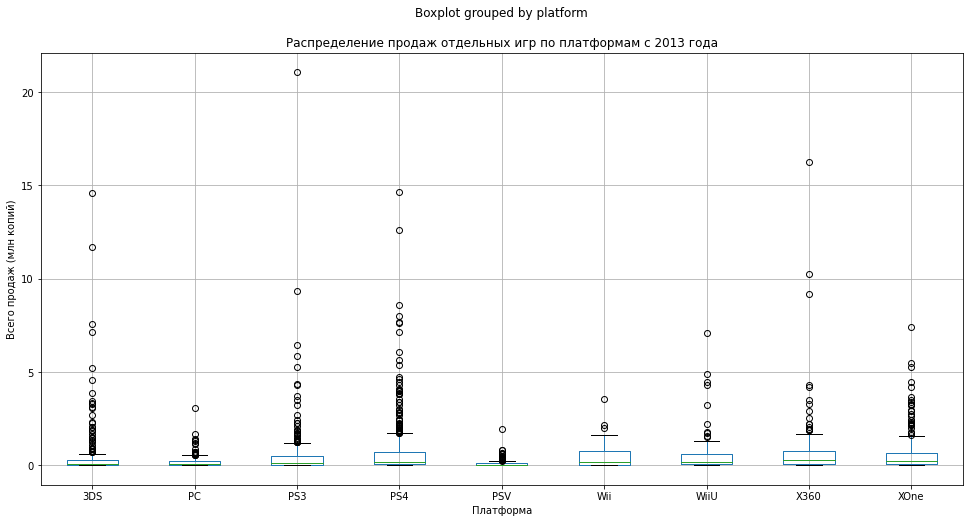

In [33]:
df_boxplot = df.query(
    "year_of_release >= 2013 & platform in ['PS4', 'PS3', 'XOne', '3DS', 'X360', 'WiiU', 'PC', 'PSV', 'Wii']"
)

df_boxplot.boxplot(
    column='total_sales',
    by='platform',
    figsize=(16, 8)
)

plt.title('Распределение продаж отдельных игр по платформам с 2013 года')
plt.xlabel('Платформа')
plt.ylabel('Всего продаж (млн копий)')

plt.show()

**Комментарии:**

Лидеры по аномальным величинам с 2013 года (хитам продаж) - PS3, PS4, X360, 3DS. Это говорит о большой разнице между продажами хитов и средними продажами игр каждой из платформ.

В плане хитов для консолей нового поколения PS4 опережает XOne, и поэтому выглядит более перспективной в будущем.

PC, PSV - очень маленькие продажи, хитов мало.

Теперь рассмотрим медианную часть и сам "ящик с усами" без аномальных выбросов (рассмотрим продажи игр до 1 млн. копий).

In [34]:
df_boxplot_q3_lim = df_boxplot.groupby('platform')['total_sales'].describe()
display(df_boxplot_q3_lim)

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,303.0,0.472772,1.381347,0.01,0.040,0.090,0.280,14.60
PC,189.0,0.208624,0.352304,0.01,0.030,0.080,0.230,3.05
PS3,345.0,0.525884,1.451939,0.01,0.040,0.150,0.510,21.05
PS4,392.0,0.801378,1.609456,0.01,0.060,0.200,0.730,14.63
PSV,358.0,0.092151,0.153816,0.01,0.020,0.040,0.110,1.96
Wii,23.0,0.593913,0.915432,0.01,0.045,0.180,0.755,3.58
WiiU,115.0,0.562000,1.038778,0.01,0.060,0.200,0.595,7.09
X360,186.0,0.735484,1.663275,0.01,0.080,0.265,0.795,16.27
XOne,247.0,0.645020,1.036139,0.01,0.060,0.220,0.685,7.39


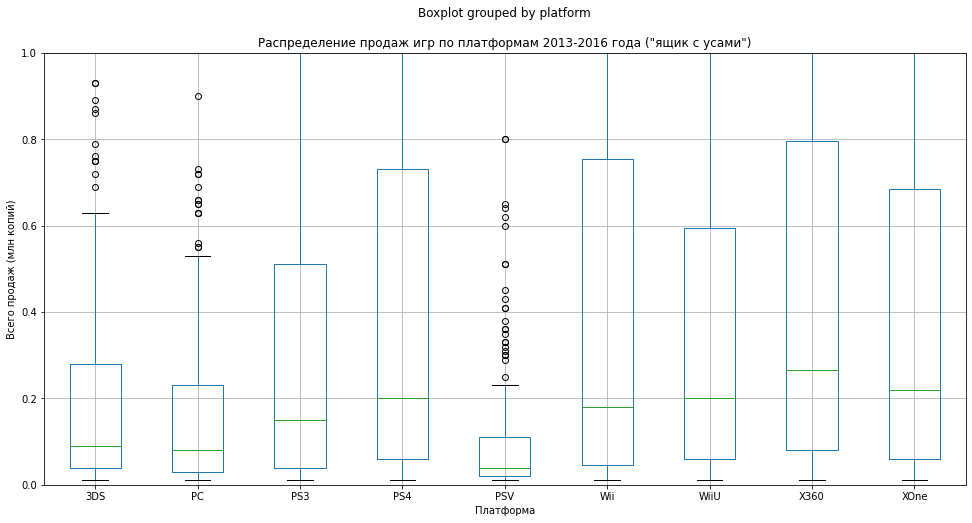

In [35]:
ax4 = df_boxplot.boxplot(
    column='total_sales',
    by='platform',
    figsize=(16, 8)
)

ax4.set_ylim(0, 1)
plt.title('Распределение продаж игр по платформам 2013-2016 года ("ящик с усами")')
plt.xlabel('Платформа')
plt.ylabel('Всего продаж (млн копий)')

plt.show()

**Комментарии:**

На данной диаграмме размаха мы ограничились верхним значением в 1.0 (максимальное значение 75% квартиля у `X360`, и оно - 0.795 млн. продаж, поэтому лимит в 1.0 был взят с запасом для наглядности)

Минимальные продажи для всех платформ равны - 0.01 млн. продаж (~10 тыс). На всех платформах были такие неуспешные проекты.

У `X360` самое большое медианное значение - 0.265 млн. продаж. Самие низкая медиана у `PSV` - 0.04 млн. продаж (40 тысяч). У остальных игровых платформ медиана держится между 0.08 и 0.22 млн. продаж. `X360` более успешна в плане "количество-качество" и благодаря множеству успешных хитов его медиана выше остальных. Проекты `PSV` не популярны. Возможно, они совсем никогда не были популярны, но в период 2013-2016 точно нет.

Наибольший межквартильный размах у `X360`, `Wii`, `PS4` и `XOne` показывает разницу в разбросах неаномальных продаж.

Наименьший межквартильный размах - у `PSV`, `PC` и `3DS`. Это наглядно показывает нам что большинство игр имеет низкий спрос относительно других платформ, их хиты находят на уровне Q3 лидеров - `PS4`, `Wii`, `X360`, `XOne`. Что еще раз подтверждает превосходство последних.

<a id="step-3-8"></a>
### Как влияют отзывы пользователей и критиков на продажи

#### 3.8.1 Оценка критиков PS4

На примере платформы PS4 рассмотрим как влияют на продажи внутри одной платформы отзывы пользователей и критиков. Построим диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами.

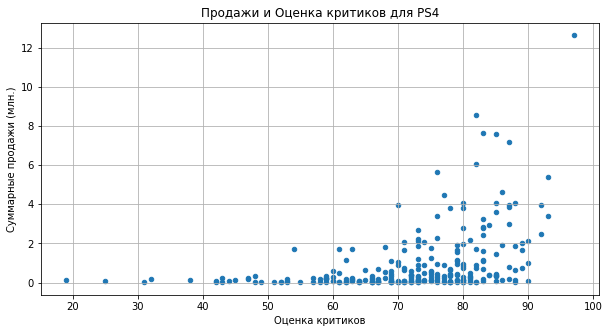

In [36]:
df_ps4 = df[
    (df['platform'] == 'PS4') &
    (df['year_of_release'] >= 2013) &
    (df['year_of_release'] <= 2016)
]

df_ps4.plot(
    x='critic_score',
    y='total_sales',
    kind='scatter',
    grid=True,
    figsize=(10, 5)
)

plt.title('Продажи и Оценка критиков для PS4')
plt.xlabel('Оценка критиков')
plt.ylabel('Суммарные продажи (млн.)')
plt.show()

In [37]:
df_ps4_critic_score_clean = df_ps4.dropna(subset=['critic_score', 'total_sales'])
corr_ps4 = df_ps4_critic_score_clean['critic_score'].corr(df_ps4_critic_score_clean['total_sales'])
corr2_ps4 = df_ps4_critic_score_clean['total_sales'].corr(df_ps4_critic_score_clean['critic_score'])

print(f'Коэффициент корреляции Оценки критиков и Продажи для PS4 = {corr_ps4}')
print(f'Коэффициент корреляции Продажи и Оценки критиков для PS4 = {corr2_ps4}')

Коэффициент корреляции Оценки критиков и Продажи для PS4 = 0.40656790206178095
Коэффициент корреляции Продажи и Оценки критиков для PS4 = 0.406567902061781


**Комментарии:**

На диаграмме видно, что: 
- игры с более высокими оценками продаются лучше. Однако, даже высокая оценка критиков не гарантирует безумных продаж;
- небольшое количество отлично продаваемых хитов с продажами свыше 6 миллионов копий, и все они получили оценки больше 80 баллов;
- игры с оценкой меньше 60 баллов плохо продаются (меньше 2 млн. продаж), без исключений.

Коэффициент корреляции 0.40 говорит о наличии связи, но не слишком сильной. Выходит, что хорошая оценка от критиков сопровождается увеличением продаж, но так бывает не всегда.

#### 3.8.2 Оценка игроков PS4

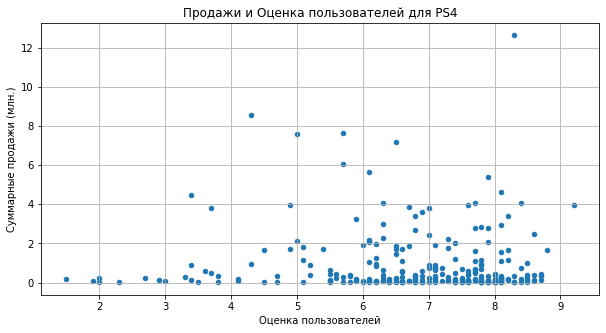

In [38]:
df_ps4.plot(
    x='user_score',
    y='total_sales',
    kind='scatter',
    grid=True,
    figsize=(10, 5)
)

plt.title('Продажи и Оценка пользователей для PS4')
plt.xlabel('Оценка пользователей')
plt.ylabel('Суммарные продажи (млн.)')
plt.show()

In [39]:
df_ps4_user_score_clean = df_ps4.dropna(subset=['user_score', 'total_sales'])
corr_ps4 = df_ps4_user_score_clean['user_score'].corr(df_ps4_user_score_clean['total_sales'])
corr2_ps4 = df_ps4_user_score_clean['total_sales'].corr(df_ps4_user_score_clean['user_score'])

print(f'коэффициент корреляции Оценки пользователей и Продажи для PS4 = {corr_ps4}')
print(f'Коэффициент корреляции Продажи и Оценки пользователей для PS4 = {corr2_ps4}')

коэффициент корреляции Оценки пользователей и Продажи для PS4 = -0.031957110204556376
Коэффициент корреляции Продажи и Оценки пользователей для PS4 = -0.031957110204556376


In [40]:
ps4_hits = df_ps4[
    (df_ps4['total_sales'] >= 6) &
    (df_ps4['critic_score'].notna()) &
    (df_ps4['user_score'].notna())
]

display(ps4_hits[['name', 'critic_score', 'user_score', 'total_sales']].sort_values('total_sales', ascending=False))

,name,critic_score,user_score,total_sales
42,Grand Theft Auto V,97.0,8.3,12.62
77,FIFA 16,82.0,4.3,8.58
92,Call of Duty: Advanced Warfare,83.0,5.7,7.66
94,FIFA 17,85.0,5.0,7.60
105,Fallout 4,87.0,6.5,7.17
143,FIFA 15,82.0,5.7,6.08


**Комментарии:**

Игры с 6+ млн. продажами могут иметь оценку игроков от 4.3 до 8.3, и оценки, которые ставят пользовали таким хитам, ниже чем у критиков.

Оценки сконценрированы на играх с продажами менее 5 миллионов, и смещены в промежуток от 6.0 до 8.0.

Нишевые игры (продажи менее 1 млн.) могут иметь высокую оценку от 9 баллов.

Корреляция в -0.03 говорит об отсутствии связи между продажами и оценками пользователей. Высокие оценки пользователей не гарантируют финансовый успех проекта, их влияние на продажи очень мало.

#### 3.8.3 Оценка критиков XOne, 3DS, PC, WiiU, PSV

Теперь разберем влияние в продажах игр для оставшихся актуальных платформах. Нас интересуют: Xbox One, Nintendo 3DS, PC, Nintendo Wii U и PS Vita.

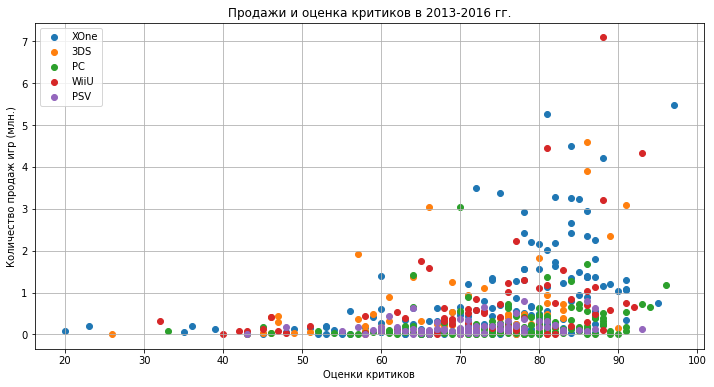

In [41]:
df_scatter = df.query("year_of_release >= 2013")

xone = df_scatter.query("platform == 'XOne'")
ds3 = df_scatter.query("platform == '3DS'")
pc = df_scatter.query("platform == 'PC'")
wiiu = df_scatter.query("platform == 'WiiU'")
psv = df_scatter.query("platform == 'PSV'")

plt.figure(figsize=(12, 6))

plt.scatter(xone['critic_score'], xone['total_sales'], label='XOne')
plt.scatter(ds3['critic_score'], ds3['total_sales'], label='3DS')
plt.scatter(pc['critic_score'], pc['total_sales'], label='PC')
plt.scatter(wiiu['critic_score'], wiiu['total_sales'], label='WiiU')
plt.scatter(psv['critic_score'], psv['total_sales'], label='PSV')

plt.title('Продажи и оценка критиков в 2013-2016 гг.')
plt.xlabel('Оценки критиков')
plt.ylabel('Количество продаж игр (млн.)')

plt.grid(True)
plt.legend()
plt.show()

In [42]:
corr_xone = xone['critic_score'].corr(xone['total_sales'])
corr2_xone = xone['total_sales'].corr(xone['critic_score'])
print(f'XOne: коэффициент корреляции Оценки критиков и Продажи = {corr_xone}')
print(f'XOne: коэффициент корреляции Продажи и Оценки критиков = {corr2_xone}')
print()

corr_ds3 = ds3['critic_score'].corr(ds3['total_sales'])
corr2_ds3 = ds3['total_sales'].corr(ds3['critic_score'])
print(f'3DS: коэффициент корреляции Оценки критиков и Продажи = {corr_ds3}')
print(f'3DS: коэффициент корреляции Продажи и Оценки критиков = {corr2_ds3}')
print()

corr_pc = pc['critic_score'].corr(pc['total_sales'])
corr2_pc = pc['total_sales'].corr(pc['critic_score'])
print(f'PC: коэффициент корреляции Оценки критиков и Продажи = {corr_pc}')
print(f'PC: коэффициент корреляции Продажи и Оценки критиков = {corr2_pc}')
print()

corr_wiiu = wiiu['critic_score'].corr(wiiu['total_sales'])
corr2_wiiu = wiiu['total_sales'].corr(wiiu['critic_score'])
print(f'WiiU: коэффициент корреляции Оценки критиков и Продажи = {corr_wiiu}')
print(f'WiiU: коэффициент корреляции Продажи и Оценки критиков = {corr2_wiiu}')
print()

corr_psv = psv['critic_score'].corr(psv['total_sales'])
corr2_psv = psv['total_sales'].corr(psv['critic_score'])
print(f'PSV: коэффициент корреляции Оценки критиков и Продажи = {corr_psv}')
print(f'PSV: коэффициент корреляции Продажи и Оценки критиков = {corr2_psv}')
print()

XOne: коэффициент корреляции Оценки критиков и Продажи = 0.4169983280084017
XOne: коэффициент корреляции Продажи и Оценки критиков = 0.41699832800840175

3DS: коэффициент корреляции Оценки критиков и Продажи = 0.3570566142288103
3DS: коэффициент корреляции Продажи и Оценки критиков = 0.35705661422881035

PC: коэффициент корреляции Оценки критиков и Продажи = 0.19603028294369382
PC: коэффициент корреляции Продажи и Оценки критиков = 0.19603028294369382

WiiU: коэффициент корреляции Оценки критиков и Продажи = 0.3764149065423912
WiiU: коэффициент корреляции Продажи и Оценки критиков = 0.3764149065423912

PSV: коэффициент корреляции Оценки критиков и Продажи = 0.2547423503068656
PSV: коэффициент корреляции Продажи и Оценки критиков = 0.25474235030686565



**Комментарии:**

У Xbox One (0.42) умеренно-положительная связь - игры с высокими оценками продаются лучше. Но оценка критиков далеко не единственный фактор хороших продаж.

WiiU (0.38) и 3DS (0.36) - у портативных консолей связь чуть послабее. Отзывы критиков влияют на продажи, но не так сильно.

PSV (0.25) и PC (0.20) - слабая связь. Видимо, другие факторы влияют сильнее на уровень продаж.

#### 3.8.4 Оценка игроков XOne, 3DS, PC, WiiU, PSV

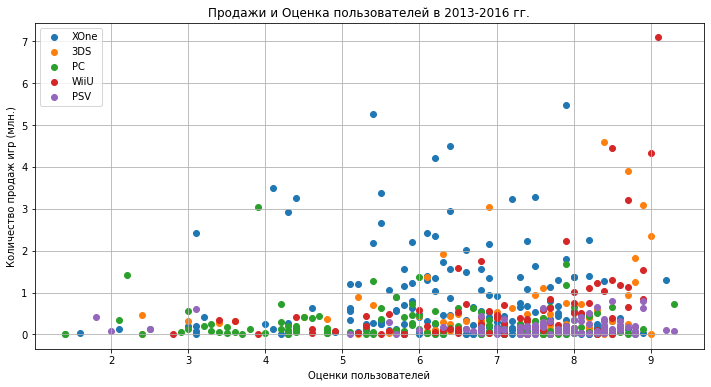

In [43]:
plt.figure(figsize=(12, 6))

plt.scatter(xone['user_score'], xone['total_sales'], label='XOne')
plt.scatter(ds3['user_score'], ds3['total_sales'], label='3DS')
plt.scatter(pc['user_score'], pc['total_sales'], label='PC')
plt.scatter(wiiu['user_score'], wiiu['total_sales'], label='WiiU')
plt.scatter(psv['user_score'], psv['total_sales'], label='PSV')

plt.title('Продажи и Оценка пользователей в 2013-2016 гг.')
plt.xlabel('Оценки пользователей')
plt.ylabel('Количество продаж игр (млн.)')

plt.grid(True)
plt.legend()
plt.show()

In [44]:
corr_xone = xone['user_score'].corr(xone['total_sales'])
corr2_xone = xone['total_sales'].corr(xone['user_score'])
print(f'XOne: коэффициент корреляции Оценки пользователей и Продажи = {corr_xone}')
print(f'XOne: коэффициент корреляции Продажи и Оценки пользователей = {corr2_xone}')
print()

corr_ds3 = ds3['user_score'].corr(ds3['total_sales'])
corr2_ds3 = ds3['total_sales'].corr(ds3['user_score'])
print(f'3DS: коэффициент корреляции Оценки пользователей и Продажи = {corr_ds3}')
print(f'3DS: коэффициент корреляции Продажи и Оценки пользователей = {corr2_ds3}')
print()

corr_pc = pc['user_score'].corr(pc['total_sales'])
corr2_pc = pc['total_sales'].corr(pc['user_score'])
print(f'PC: коэффициент корреляции Оценки пользователей и Продажи = {corr_pc}')
print(f'PC: коэффициент корреляции Продажи и Оценки пользователей = {corr2_pc}')
print()

corr_wiiu = wiiu['user_score'].corr(wiiu['total_sales'])
corr2_wiiu = wiiu['total_sales'].corr(wiiu['user_score'])
print(f'WiiU: коэффициент корреляции Оценки пользователей и Продажи = {corr_wiiu}')
print(f'WiiU: коэффициент корреляции Продажи и Оценки пользователей = {corr2_wiiu}')
print()

corr_psv = psv['user_score'].corr(psv['total_sales'])
corr2_psv = psv['total_sales'].corr(psv['user_score'])
print(f'PSV: коэффициент корреляции Оценки пользователей и Продажи = {corr_psv}')
print(f'PSV: коэффициент корреляции Продажи и Оценки пользователей = {corr2_psv}')
print()

XOne: коэффициент корреляции Оценки пользователей и Продажи = -0.06892505328279414
XOne: коэффициент корреляции Продажи и Оценки пользователей = -0.06892505328279412

3DS: коэффициент корреляции Оценки пользователей и Продажи = 0.24150411773563016
3DS: коэффициент корреляции Продажи и Оценки пользователей = 0.24150411773563016

PC: коэффициент корреляции Оценки пользователей и Продажи = -0.0938418695247674
PC: коэффициент корреляции Продажи и Оценки пользователей = -0.09384186952476739

WiiU: коэффициент корреляции Оценки пользователей и Продажи = 0.4193304819266187
WiiU: коэффициент корреляции Продажи и Оценки пользователей = 0.4193304819266187

PSV: коэффициент корреляции Оценки пользователей и Продажи = 0.0009424723319108626
PSV: коэффициент корреляции Продажи и Оценки пользователей = 0.0009424723319108626



**Комментарии:**

PC (-0.09), Xbox One (-0.07), PSV (0.00) - околонулевая связь, ее отсутствие. Отзывы пользователей никак не влияют на объёмы продаж. Возможно, что оценки пользователей не всегда объективны.

WiiU (0.42) и 3DS (0.24) - средняя и средне-слабая связь. Влияние игроков имеется. У WiiU коэффициент корреляции пользователей даже выше, чем у критиков. Возможно, что рынок портативных консолей настолько мал, что отзывы пользователей - весьма объективный источник информации, а сообщества Nintendo (родитель обеих консолей) очень лояльны к своим играм.

<a id="step-3-9"></a>
### 3.9 Распределение игр по жанрам

Рассмотрим общее распределение игр по жанрам

In [45]:
df_filtered_last_4years = df.query('year_of_release >= 2013')
display(df_filtered_last_4years.head(10))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,No Rating,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,No Rating,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,4.35,3.49,3.10,0.74,NaN,NaN,No Rating,11.68
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.10,3.63,0.38,1.25,71.0,2.6,M,9.36
72,Minecraft,X360,2013,Misc,5.70,2.65,0.02,0.81,NaN,NaN,No Rating,9.18
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58


In [46]:
genre_stats2016 = (
    df_filtered_last_4years
    .groupby('genre')['total_sales']
    .agg(total_sales_by_genre='sum', mean_sales='mean', median_sales='median', count_games='count')
    .sort_values('total_sales_by_genre', ascending=False)
)

display(genre_stats2016)

,total_sales_by_genre,mean_sales,median_sales,count_games
genre,,,,
Action,321.87,0.420196,0.110,766
Shooter,232.98,1.245882,0.450,187
Sports,150.65,0.703972,0.240,214
Role-Playing,145.89,0.499623,0.125,292
Misc,62.82,0.405290,0.100,155
Platform,42.63,0.576081,0.225,74
Racing,39.89,0.469294,0.120,85
Fighting,35.31,0.441375,0.125,80
Adventure,23.64,0.096490,0.030,245


**Комментарии:**

C 2013 по 2016 года больше всего продаж в жанре `Action` - 321.87 миллионов копий, но в среднем одна игра жанра `Shooter` дает больше продаж (среднее значение - 1.25 млн., медианное - 0.45 млн; разница между средней и медианой говорит о большой разнице между лидерами и неуспешными проектами), последний из топ 3 - `Sports`.

`Grand Theft Auto V` - лидер продаж на крупных платформах (PS3, Xbox 360, PS4).

Больше всего игр жанра `Action` -  766 штуки за эти года и 321.87 млн. продаж, затем идет `Role-Playing` (292 шт. и 145.89 млн. копий) и `Adventure` (245 шт. и 23.64 млн. копий).

`Strategy` отличаются с очень плохой стороны - наименьшее число общих продаж за 4 года - 10.08 млн. копий, один из самых непопулярных жанров. Меньше игр только у жанра `Puzzle` 3.17 млн. проданных игр и 17 игр за 4 года.

<a id="step-3-10"></a>
### 3.10 Вывод подраздела

Жизненный цикл игровой платформы составляет около 7 лет, при этом стандартное отклонение составляет 5 лет.

Почти каждый год появляется новая игровая платформа. Это значит, что каждая новая консоль проживет от 2,7 до 12,7 лет.

Продажи по платформам в 2016 году - лидирует PS4 (69.25 млн. проданных игр), затем XOne (26.15 млн.) и 3DS (15.14 млн.)


Больше всего хитов (аномальных продаж 1 игры) с 2013 по 2016 год у PS3, PS4, X360, 3DS. Их аномальность в большом разрыве между продажами хитов и средними продажами игр каждой из платформ. Бестселлеров у PS4 больше, чем у XOne, и поэтому она выглядит более перспективной в будущем.

Влияние оценок - для игр платформ PS4, XOne, WiiU, 3DS оценка критиков влияет на продажи. Для PC это относится в меньшей степени.

Корреляция критиков и продаж средняя (0.4), а пользовательские рейтинги слабо связаны с объёмом продаж (0.14). Это говорит о большом влиянии отзывов критиков на продажи и может помочь в будущем прогнозировании.

Активные жанры (Action, Shooter, Sports) приносят наибольшие средние продажи, тогда как паззлы, стратегии и приключения пользуются наименьшим успехом.

<a id="step-4"></a>
## Шаг 4. Портрет пользователя каждого региона

Определим для геймера каждого из регионов - игры каких платформ и какие жанры пользуются спросом именно у них.

Разберем влияет ли возрастной рейтинг на продажи в отдельном регионе.

<a id="step-4-1"></a>
### 4.1 Самые популярные платформы каждого региона (NA, EU, JP)

In [47]:
platform_total_sales_number = sales_until_2015_pivot.sum().sum()
print(f'Продано всего игр с 2013 по 2016 года: {platform_total_sales_number:.2f} млн.')

Продано всего игр с 2013 по 2016 года: 2171.30 млн.


#### Северная Америка

In [48]:
df_filtered_2013_2016 = df.query('year_of_release >= 2013')

platform_totals_na = (df_filtered_2013_2016
    .groupby('platform')['na_sales']
    .sum()
    .sort_values(ascending=False)
)

total_sales_na = platform_totals_na.sum()
share_na = (platform_totals_na / total_sales_na * 100).round(1)

sales_na_table = pd.DataFrame({
    'sales_na': platform_totals_na,
    'share_na': share_na
})

print(f'Продано игр в NA с 2013 по 2016 года: {total_sales_na:.2f} млн.')
print('Топ 5 платформ в NA и их доли (%):')
display(sales_na_table.head())

Продано игр в NA с 2013 по 2016 года: 437.71 млн.
Топ 5 платформ в NA и их доли (%):


,sales_na,share_na
platform,,
PS4,108.74,24.8
XOne,93.12,21.3
X360,81.66,18.7
PS3,63.50,14.5
3DS,38.20,8.7


In [49]:
na_xbox_ps = (
    df.query("platform in ['PS3', 'PS4', 'XOne', 'X360'] and 2013 <= year_of_release <= 2016")
    .pivot_table(
        index='year_of_release',
        columns='platform',
        values='na_sales',
        aggfunc='sum'
    )
)

na_xbox_ps.loc['total_sales'] = na_xbox_ps.sum()

display(na_xbox_ps)

platform,PS3,PS4,X360,XOne
year_of_release,,,,
2013,41.45,10.13,53.36,11.85
2014,16.39,34.75,20.25,30.97
2015,4.99,42.37,7.36,36.03
2016,0.67,21.49,0.69,14.27
total_sales,63.50,108.74,81.66,93.12


**Комментарии:**

В регионе NA в период с 2013 по 2016 года было продано 437.71 миллиона игр.

Игры на консоль PS4 пользуются наибольшим спросом в этом регионе - 108.74 миллиона проданных игр для этой игровой платформы, а это составляет 24.8% рынка NA.

Общая американской компании Microsoft с их Xbox One (21.3%) и Xbox 360 (18.7%) - 40% от всех продаж на северо-американском рынке в эти годы.  

Общая доля Sony с их PS4 и PS3 составляет чуть меньше - 39.3% северо-американского рынка (без учета портативной консоли PSV с 1.2%).

В NA регионе представлены 2 крупных игрока, которые стараются не отставать друг от друга. И хотя в 2013-2014 Xbox 360 опережал по продажам PS3, с выходом нового поколения ситуация поменялась - с 2015 на PS4 игр продается больше, чем на Xbox One.

#### Европа

In [50]:
platform_totals_eu = (df_filtered_2013_2016
    .groupby('platform')['eu_sales']
    .sum()
    .sort_values(ascending=False)
)

total_sales_eu = platform_totals_eu.sum()
share_eu = (platform_totals_eu / total_sales_eu * 100).round(1)

sales_eu_table = pd.DataFrame({
    'sales_eu': platform_totals_eu,
    'share_eu': share_eu
})

print(f'Продано игр в EU с 2013 по 2016 года: {total_sales_eu:.2f} млн.')
print('Топ 5 платформ в EU и их доли (%):')
display(sales_eu_table.head())

Продано игр в EU с 2013 по 2016 года: 392.23 млн.
Топ 5 платформ в EU и их доли (%):


,sales_eu,share_eu
platform,,
PS4,141.09,36.0
PS3,67.81,17.3
XOne,51.59,13.2
X360,42.52,10.8
3DS,30.96,7.9


**Комментарии:**

Отметим, что европейский игровой рынок немного меньше северо-американского. С 2013 по 2016 год в EU было продано 392.23 миллиона игр для разных игровых платформ.

Обе консоли PlayStation пользуются популярностью в EU, и вместе занимают большую половину европейского рынка (53.3%). Первое место - PS4 (36%), второе - PS3 (17.3%).

На европейском рынке консоли Microsoft значительно проигрывают по продажам их игр. XOne - третье место, и всего лишь 13.2% европейского рынка. X360 еще меньше - 10.8%. Или 94.11 млн. проданных игр вместе (`XOne` + `X360`), а эта цифра почти в 2 раза меньше чем в NA.

#### Япония

In [51]:
platform_totals_jp = (df_filtered_2013_2016
    .groupby('platform')['jp_sales']
    .sum()
    .sort_values(ascending=False)
)

total_sales_jp = platform_totals_jp.sum()
share_jp = (platform_totals_jp / total_sales_jp * 100).round(1)

sales_jp_table = pd.DataFrame({
    'sales_jp': platform_totals_jp,
    'share_jp': share_jp
})

print(f'Продано игр в JP с 2013 по 2016 года: {total_sales_jp:.2f} млн.')
print('Топ 5 платформ в JP и их доли (%):')
display(sales_jp_table)

Продано игр в JP с 2013 по 2016 года: 140.78 млн.
Топ 5 платформ в JP и их доли (%):


,sales_jp,share_jp
platform,,
3DS,67.81,48.2
PS3,23.35,16.6
PSV,18.59,13.2
PS4,15.96,11.3
WiiU,10.88,7.7
PSP,3.29,2.3
X360,0.51,0.4
XOne,0.34,0.2
Wii,0.05,0.0


In [52]:
jp_ps3_ps4 = (
    df.query("platform in ['PS3', 'PS4'] and 2013 <= year_of_release <= 2016")
    .pivot_table(
        index='year_of_release',
        columns='platform',
        values='jp_sales',
        aggfunc='sum'
    )
)

jp_ps3_ps4.loc['total_sales'] = jp_ps3_ps4.sum()

display(jp_ps3_ps4)

platform,PS3,PS4
year_of_release,,
2013,12.13,0.94
2014,6.25,2.97
2015,3.67,6.31
2016,1.30,5.74
total_sales,23.35,15.96


**Комментарии:**

В японском регионе ситуация иная. Этот рынок еще меньше - 140.78 млн проданных игр с 2013 по 2016 год.

Если 3DS не пользовались популярностью в EU (5 место, 7.9% и 30.96 млн проданных игр) и NA (5 место, 8.7% и 38.20 млн. проданных игр), то в JP эта платформа на первом месте с долей почти половины рынка 48.2% и с продажами игр в 48.2 млн.. Это почти в 6 раз меньше, чем в EU или NA.

В этом регионе доля портативных игровых платформ, а именно 3DS, PSV, WiiU и PSP (2.3%) - 71.4%. Грубо говоря, у каждого второго из трех геймеров дома есть одна из этих консолей.

Игры на PS3 в 2013-2016 гг. продавались лучше, чем PS4 - 23.35 миллиона и 15.96 миллиона соответственно. Из дополнительной таблицы видно, что в японском регионе была более медленная смена поколений консоли и игроки не сразу перешли на новую PS4 - продажи на PS3 в 2013-2014 годах превышали продажи на PS4.

Доля X360 в JP регионе - 0.4%, XOne - 0.2%. Консоли Microsoft совсем не пользуются спросом в этом регионе, в то время как японские производители Sony (PS4, PS3, PSV, PSP) и Nintendo (3DS, WiiU, Wii, DS) охватывают чуть больше 99% японского рынка.

<a id="step-4-2"></a>
### 4.2 Топ 5 жанров каждого региона

#### Северная Америка

In [53]:
genre_totals_na = (df_filtered_2013_2016
    .groupby('genre')['na_sales']
    .sum()
    .sort_values(ascending=False)
)

total_sales_na = genre_totals_na.sum()
share_na = (genre_totals_na / total_sales_na * 100).round(1)

genre_na_table = pd.DataFrame({
    'sales_na': genre_totals_na,
    'share_na': share_na
})

print(f'Продано игр в NA по жанрам с 2013 по 2016 года: {total_sales_na:.2f} млн.')
print('Топ 5 жанров в NA и их доли (%):')
display(genre_na_table.head())

Продано игр в NA по жанрам с 2013 по 2016 года: 437.71 млн.
Топ 5 жанров в NA и их доли (%):


,sales_na,share_na
genre,,
Action,126.05,28.8
Shooter,109.74,25.1
Sports,65.27,14.9
Role-Playing,46.40,10.6
Misc,27.49,6.3


**Комментарии:**

В NA предпочтительны активные жанры - `Action`, `Shooter`, `Sports`. В сумме жанры занимают 68,8% их рынка

Лидер продаж - `Action`, 126.05 млн. копий и с долей региона 28.8%.

#### Европа

In [54]:
genre_totals_eu = (df_filtered_2013_2016
    .groupby('genre')['eu_sales']
    .sum()
    .sort_values(ascending=False)
)

total_sales_eu = genre_totals_eu.sum()
share_eu = (genre_totals_eu / total_sales_eu * 100).round(1)

genre_eu_table = pd.DataFrame({
    'sales_eu': genre_totals_eu,
    'share_eu': share_eu
})

print(f'Продано игр в EU по жанрам с 2013 по 2016 года: {total_sales_eu:.2f} млн.')
print('Топ 5 жанров в EU и их доли (%):')
display(genre_eu_table.head())

Продано игр в EU по жанрам с 2013 по 2016 года: 392.23 млн.
Топ 5 жанров в EU и их доли (%):


,sales_eu,share_eu
genre,,
Action,118.13,30.1
Shooter,87.86,22.4
Sports,60.52,15.4
Role-Playing,36.97,9.4
Racing,20.19,5.1


**Комментариии:**

В европейском регионе происходит повторение картины, и EU геймеры тоже выбирают активные жанры - `Action`, `Shooter`, `Sports`. В сумме эти жанры занимают 67,9% рынка, что близко к доли этих жанров в NA.

1 место - `Action`, 118.13 млн. продаж и 30.1%. Несильно отстают по этому жанру с Северной Америкой.

На 4 месте, как и в Америке, находится жанр `Role-Playing` с долей 9.4% и 36.97 млн. проданных игр этого жанра.

Также отметим, что европейцы чаще выбирают жанр `Racing` чем в NA. В EU - 20.19 млн. проданных копий (5.1%), а в NA - 12.96 млн (3%).

#### Япония

In [55]:
genre_totals_jp = (df_filtered_2013_2016
    .groupby('genre')['jp_sales']
    .sum()
    .sort_values(ascending=False)
)

total_sales_jp = genre_totals_jp.sum()
share_jp = (genre_totals_jp / total_sales_jp * 100).round(1)

genre_jp_table = pd.DataFrame({
    'sales_jp': genre_totals_jp,
    'share_jp': share_jp
})

print(f'Продано игр в JP по жанрам с 2013 по 2016 года: {total_sales_jp:.2f} млн.')
print('Топ 5 жанров в JP и их доли (%):')
display(genre_jp_table.head())

Продано игр в JP по жанрам с 2013 по 2016 года: 140.78 млн.
Топ 5 жанров в JP и их доли (%):


,sales_jp,share_jp
genre,,
Role-Playing,51.04,36.3
Action,40.49,28.8
Misc,9.20,6.5
Fighting,7.65,5.4
Shooter,6.61,4.7


**Комментариии:**
    
На первом месте в Японии - жанр `Role-Playing`, и с 2013 по 2016 годы он занимает 36.3% от рынка. Проданных игр этого жанра (51.04 млн.) опережают цифры из NA (46.40 млн. и 4 место там).

Почти две трети рынка (65.1%) занимают сумма жанров `Role-Playing` + `Action` (28.8%). Очень специфичный регион. Возможно, это связано с тем, что в эти жанры удобно играть на портативных консолях, которые пользуются популярностью там.

Также отметим интерес японцев к `Fighting` - 4 место, 5.4% и 7.65 миллиона проданных игр за 2013-2016 года.

<a id="step-4-3"></a>
### 4.3 Влияние рейтинга ESRB на продажи в регионах

Для анализа выберем регион NA как самый крупный, и рассмотрим продажи там в разрезе возрастного рейтинга и их влияние.

Затем по аналогии рассмотрим результаты для регионов EU и JP.

#### Северная Америка

In [56]:
rating_totals_na = (df_filtered_2013_2016
    .groupby('rating')['na_sales']
    .sum()
    .sort_values(ascending=False)
)

total_sales_na = rating_totals_na.sum()
share_na = (rating_totals_na / total_sales_na * 100).round(1)

rating_na_table = pd.DataFrame({
    'sales_na': rating_totals_na,
    'share_na': share_na
})

print(f'Продано игр в NA с 2013 по 2016 года: {total_sales_na:.2f} млн.')
print('Топ 5 рейтингов игр в NA и их доли (%):')
display(rating_na_table.head())

Продано игр в NA с 2013 по 2016 года: 437.71 млн.
Топ 5 рейтингов игр в NA и их доли (%):


,sales_na,share_na
rating,,
M,165.21,37.7
No Rating,89.42,20.4
E,79.05,18.1
E10+,54.24,12.4
T,49.79,11.4


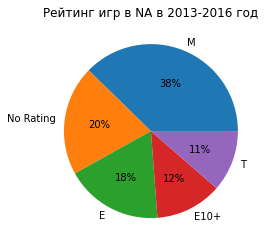

In [57]:
share_na.plot(
    kind='pie',
    title='Рейтинг игр в NA в 2013-2016 год',
    ylabel='',
    autopct='%.0f%%'
)

plt.show()

In [58]:
rating_counts = (df_filtered_2013_2016
    .groupby('rating')['na_sales']
    .count()
)

rating_na_table = pd.DataFrame({
    'sales_na': rating_totals_na,
    'share_na': share_na,
    'game_count': rating_counts,
})

rating_na_table['avg_sales'] = (rating_na_table['sales_na'] / rating_na_table['game_count']).round(2)
rating_na_table = rating_na_table.sort_values(by='sales_na', ascending=False)

print(f'Продано игр в NA с 2013 по 2016 года: {total_sales_na:.2f} млн.')
print('Топ 5 рейтингов игр в NA:')
display(rating_na_table)

Продано игр в NA с 2013 по 2016 года: 437.71 млн.
Топ 5 рейтингов игр в NA:


,sales_na,share_na,game_count,avg_sales
rating,,,,
M,165.21,37.7,369,0.45
No Rating,89.42,20.4,977,0.09
E,79.05,18.1,302,0.26
E10+,54.24,12.4,252,0.22
T,49.79,11.4,333,0.15


**Комментарии:**

Информация о возрастных рейтингах:

- Рейтинг E (Everyone) - для всех возрастов
- Рейтинг E10+ (Everyone 10+) - с 10 лет; умеренное насилие или юмор чуть постарше
- Рейтинг T (Teen) - от 13 лет; наличие умеренных сцен насилия, сдержанная нецензурная лексика
- Рейтинг M (Mature) - от 17 лет; яркие сцены насилия, более жёсткая лексика, могут быть сексуальные намёки
- AO (Adults Only) - только 18+; явные сцены насилия или секса
- RP (Rating Pending) - рейтинг ожидается

Из данной таблицы на примере региона NA мы видим, что больше всего продаж игр было для `М` рейтинга (17+) - 165.21 миллиона проданных игр (37.7%%). Далее следует игры без рейтинга (89.42 млн, 20.4%) и `Е` для всех (79.05 млн., 18.1%).

Игры рейтинга ЕС, АО и RP отсутствуют вовсе.

О чем это может говорить? Игры с рейтингом `М` пользуются наибольшим спросом и продаж в среднем на 1 игру делают больше (0.45 млн.), чем игры с прочими рейтингами. 

Наличие игр без рейтинга может быть обусловено большим количеством проектов, которые не проходили возрастной рейтинг, либо их рейтинг не был учтен в исходных данных. Данная категории помечена как `No Rating` для всех регионов.

#### Европа

In [59]:
rating_totals_eu = (df_filtered_2013_2016
    .groupby('rating')['eu_sales']
    .sum()
    .sort_values(ascending=False)
)

rating_counts_eu = (df_filtered_2013_2016
    .groupby('rating')['eu_sales']
    .count()
)

total_sales_eu = rating_totals_eu.sum()
share_eu = (rating_totals_eu / total_sales_eu * 100).round(1)

rating_eu_table = pd.DataFrame({
    'sales_eu': rating_totals_eu,
    'share_eu': share_eu,
    'game_count': rating_counts_eu,
})

rating_eu_table['avg_sales'] = (rating_eu_table['sales_eu'] / rating_eu_table['game_count']).round(2)
rating_eu_table = rating_eu_table.sort_values(by='sales_eu', ascending=False)

print(f'Продано игр в EU с 2013 по 2016 годах: {total_sales_eu:.2f} млн.')
print('Топ 5 рейтингов игр в EU:')
display(rating_eu_table.head())

Продано игр в EU с 2013 по 2016 годах: 392.23 млн.
Топ 5 рейтингов игр в EU:


,sales_eu,share_eu,game_count,avg_sales
rating,,,,
M,145.32,37.0,369,0.39
E,83.36,21.3,302,0.28
No Rating,78.91,20.1,977,0.08
E10+,42.69,10.9,252,0.17
T,41.95,10.7,333,0.13


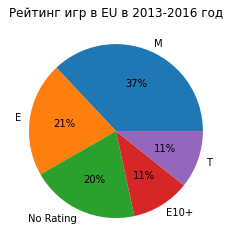

In [60]:
share_eu.plot(
    kind='pie',
    title='Рейтинг игр в EU в 2013-2016 год',
    ylabel='',
    autopct='%.0f%%'
)

plt.show()

**Комментарии:**
    
Аналогичная ситуация в EU. Здесь больше игр с рейтингом `М` и в среднем они пользуются большей популярностью.

#### Япония

In [61]:
rating_totals_jp = (df_filtered_2013_2016
    .groupby('rating')['jp_sales']
    .sum()
    .sort_values(ascending=False)
)

rating_counts_jp = (df_filtered_2013_2016
    .groupby('rating')['jp_sales']
    .count()
)

total_sales_jp = rating_totals_jp.sum()
share_jp = (rating_totals_jp / total_sales_jp * 100).round(1)

rating_jp_table = pd.DataFrame({
    'sales_jp': rating_totals_jp,
    'share_jp': share_jp,
    'game_count': rating_counts_jp,
})

rating_jp_table['avg_sales'] = (rating_jp_table['sales_jp'] / rating_jp_table['game_count']).round(2)
rating_jp_table = rating_jp_table.sort_values(by='sales_jp', ascending=False)

print(f'Продано игр в JP с 2013 по 2016 годах: {total_sales_jp:.2f} млн.')
print('Топ 5 рейтингов игр в JP:')
display(rating_jp_table.head())

Продано игр в JP с 2013 по 2016 годах: 140.78 млн.
Топ 5 рейтингов игр в JP:


,sales_jp,share_jp,game_count,avg_sales
rating,,,,
No Rating,85.05,60.4,977,0.09
T,20.59,14.6,333,0.06
E,15.14,10.8,302,0.05
M,14.11,10.0,369,0.04
E10+,5.89,4.2,252,0.02


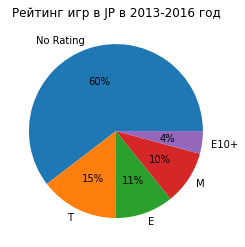

In [62]:
share_jp.plot(
    kind='pie',
    title='Рейтинг игр в JP в 2013-2016 год',
    ylabel='',
    autopct='%.0f%%'
)

plt.show()

**Комментарии:**
    
Совсем иная ситуация в регионе JP. Больше продаж игр без рейтинга (85.05 млн., 60.4%) и с рейтингом `Т` (20.59 млн., 20.59%). Возможно, что в регионе действует другой вид возрастных ограничений или существуют другие особенностями маркировки игр, не отображенные в исходных данных.

Мы рассчитали количество игр каждого из возрастного рейтинга, затем выявили сколько в среднем продаж приходится на 1 игру. Несмотря на то, что рейтинг `Е` ориентирован на более широкую аудиторию, получение рейтинга с этой буквой не может гарантировать коммерческий успех игры.

Игры категории `М` продаются в среднем больше, чем остальные.

<a id="step-4-3"></a>
### 4.4 Вывод подраздела:

NA - самый крупный игровой регион. В период с 2013 по неполный 2016 год там было продано 437.71 миллиона игр. И хотя 21.3% проданных игр там за это время приходятся на последнюю модель консоли американской компании Microsoft, самая популярная игровая платформа этого региона - PS4 (108.74 млн игр, 24.8% рынка). Эти две компании - Sony и Microsoft активно конкурируют между собой в этом регионе. В NA любят активные жанры: Action, Shooter и Sports, и вместе они составляют 68,8% рынка. На первом месте - жанр Action, 126.05 млн. продаж и 28.8% всех проданных игр в этом регионе.

В EU общий объём продаж для всех платформ за этот же период - 392.23 миллионов игр, и это второй по величине рынок. Консоли PlayStation - PS4 и PS3 лидируют в регионе, вместе занимая более половины продаж (53.3%). Жанровые предпочтения у европейцев схожи с северо-американцами - первые тоже предпочитают активные жанры - Action, Sports и Shooter. В сумме эти жанры тоже занимают примерно около 68% рынка, как и в NA.

Игровой рынок JP гораздо скромнее -  141 миллион игр за 2013-2016 год, и предпочтения геймеров более специфичные. Японцам нравятся небольшие портативные консоли - 3DS, PSV, PSP, которые вместе занимают 2/3 игрового рынка (63,7%). Cамая любимая игровая платформа японцев - 3DS, а второе место занимает PS4. Отметим, японский рынок отреагировал консервативно на новую модель и что переход с PS3 на PS4 занял чуть больше времени, чем в EU и NA. Из жанров японцы предпочитают RPG (36%), а популярного в EU и NA жанра Shooter в топе не обнаружено.

Хотя игры с рейтингом для всех возрастов (рейтинг "Е") охватывают большую аудиторию, игры с рейтингом M продаются в среднем больше и лучше во всех регионах, чем игры с другими рейтингами.

<a id="step-5"></a>
## Шаг 5. Проверка гипотез

<a id="step-5-1"></a>
### 5.1 Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Н0: Средний пользовательский рейтинг платформы PC равен среднему пользовательскому рейтингу Xbox One.

Н1: Средний пользовательский рейтинг платформы PC не равен среднему пользовательскому рейтингу Xbox One

In [63]:
scores_xone = (df_filtered_2013_2016.loc[df_filtered_2013_2016['platform'] == 'XOne', 'user_score'].dropna())
scores_pc = (df_filtered_2013_2016.loc[df_filtered_2013_2016['platform'] == 'PC', 'user_score'].dropna())

alpha = 0.05
results = st.ttest_ind(scores_xone, scores_pc, alternative='two-sided')
print(f'p-значение: {results.pvalue}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-значение: 0.14012658403611647
Нет оснований отвергнуть нулевую гипотезу


**Комментарии:**

При классическом уровне значимости в 5%, нет оснований отвергнуть нулевую гипотезу. Средние пользовательские рейтинги Xbox One и PC не различаются.

<a id="step-5-2"></a>
### 5.2 Средние пользовательские рейтинги жанров Action и Sports разные

Н0: Средний пользовательский рейтинг жанра Action равен среднему пользовательскому рейтингу жанра Sports.

Н1: Средний пользовательский рейтинг жанра Action не равен среднему пользовательскому рейтингу жанра Sports.

In [64]:
user_scores_action = (df_filtered_2013_2016.loc[df_filtered_2013_2016['genre'] == 'Action', 'user_score'].dropna())
user_scores_sports = (df_filtered_2013_2016.loc[df_filtered_2013_2016['genre'] == 'Sports', 'user_score'].dropna())

alpha = 0.05
results = st.ttest_ind(user_scores_action, user_scores_sports, alternative='two-sided')
print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-значение: 1.0517832389140023e-27
Отвергаем нулевую гипотезу


**Комментарии:**

При классическом уровне значимости в 5%, нулевая гипотеза отвергается. Средний пользовательский рейтинг жанра Action отличается от среднего пользовательского рейтинга жанра Sports.

<a id="step-5-3"></a>
### 5.3 Вывод подраздела:

Средние рейтинги от пользователей Xbox One и PC схожи. Возможно, это связано с тем, что большинство игр начало выходить как на PC, так на Xbox, и геймплейно между собой их различия минимальны.

Cредний пользовательский рейтинг жанра Action отличается от среднего пользовательского рейтинга жанра Sports.

<a id="step-6"></a>
## Шаг 6. Общий вывод

В данной работе мы изучали и использовали исторические данные с 1980 по 2016 года о продажах игр, оценки пользователей и экспертов, их жанры и платформы. Мы попробовали выявить закономерности, определяющие успешность. Это поможет нам спланировать рекламные кампании для нашего интернет-магазина Стримчик. Вот что мы выяснили:

Игровая индустрия пережила пик в 2008 году, после чего темпы роста снизились, рынок начал стабилизироваться.

Срок жизни игровых платформ около 7 лет, и почти каждый год появляется новая игровая платформа.

В 2016 году наибольшую перспективу показывают PS4 и Xbox One (обе вышли в свет в 2013 году), которые показывают рост и высокие продажи. Плюс прошлые поколения этих двух консолей - PS2, Xbox 360 и PS3 исторически занимают топ 1, топ 2 и топ 3 платформ по продажам игр за все время, что подтверждает важность консолей нового поколения от производителей Sony (PS) и Microsoft (Xbox).

Хорошие оценки критиков - хороший знак для больших продаж, но так бывает не всегда.

Связь между оценками критиков и продажами выражена сильнее, чем между пользовательскими оценками и продажами. Отличные оценки игроков сами по себе не являются надежным индикатором коммерческого успеха игры.

Action, Sports, Shooter - наиболее продаваемые жанры в регионах EU и NA. Стратегии, пазлы и приключения не пользуются широкой популярностью.

Регионы EU, NA, JP имеют свои особенности:

1. Северно-американский - самый крупный игровой регион (437.71 млн. проданных игр в 2013-2016 годах), популярностью там пользуются PS4 (24.8%) и активные жанры - Action, Sports, Shooter (68.8% рынка). Microsoft и Sony очень активно соперничают между собой в этом регионе, и на двоих занимают 80% северо-американского рынка.

2. Продаж игр в европейском регионе меньше - 392.23 млн. игр. Он тоже любит активные жанры (68.8% проданных игр в регионе), но предпочитает игры на PS4 (36.0%). Xbox обоих поколений значительно проигрывает PS.

3. Японский регион небольшой и отличный от остальных. Японцы любят переносные портативные консоли (71% рынка), жанр RPG (36%) и довольно консервативны в обновлении консолей.

Игры рейтинга Е (для всех) охватывают наибольшую аудиторию, но чаще всего наиболее продающиеся - игры с рейтингом М (17+). В Японии больше продаются игр без рейтинга. Игры с рейтингом EC, AO, RP практически не продаются ни в одном из регионов.

Также, в ходе проверки гипотез пришли к выводу, что средние пользовательские рейтинги Xbox One и PC равны, а пользовательский рейтинг жанра Action не равен среднему пользовательскому рейтингу жанра Sports.